## En caso de ejecutar este notebook desde Google Colab Ejecutar la siguiente linea, en caso de que no omitir esta parte

In [2]:
""""
import pandas as pd
import data_profiling
from data_profiling import ProfileReport
df=pd.read_csv("Spotify_Corregido.xlsx")
df = df.drop(columns=['Unnamed: 0'])

profile = ProfileReport(df, title="Reporte de Perfilado de Datos")
profile.to_file("/reports/Informe_Ejecutivo.html")

"""

'"\nimport pandas as pd\nimport data_profiling\nfrom data_profiling import ProfileReport\ndf=pd.read_csv("Spotify_Corregido.xlsx")\ndf = df.drop(columns=[\'Unnamed: 0\'])\n\nprofile = ProfileReport(df, title="Reporte de Perfilado de Datos")\nprofile.to_file("/reports/Informe_Ejecutivo.html")\n\n'

# Informe EDA

1. Carga de librerias

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import os
import sys
"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))


2. Carga del dataset

In [4]:
df=pd.read_excel("../dataset/Spotify_Corregido.xlsx")

3. Vision General del Dataset

In [5]:
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nTipos de datos:")
print(df.dtypes.value_counts())
print("\nPrimeras filas:")
print(df.head(5))
print("\nInfo detallada")
df.info()


Filas: 114000 | Columnas: 20
Memoria usada: 48.79 MB

Tipos de datos:
float64    9
object     5
int64      5
bool       1
Name: count, dtype: int64

Primeras filas:
                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55  

4. Calidad de datos

In [6]:
from utils.c_datos import (
    valores_nulos,
    duplicados,
    valores_unicos
)

resultado_nulos = valores_nulos(df)
resultado_duplicados = duplicados(df)
resultado_unicos = valores_unicos(df)

Valores nulos por columna:
            nulos  porcentaje_%
artists         1      0.000877
album_name      1      0.000877
track_name      1      0.000877
Filas duplicadas: 450 (0.39%)
                     track_id  \
52714  00JZ83w0Qm09f4PwWj06sM   
52766  00JZ83w0Qm09f4PwWj06sM   
39275  02KmEChUwcjxG3G29kbLFT   
39307  02KmEChUwcjxG3G29kbLFT   
93331  02MRylJ1WAgxzdqfNfdIsR   
93376  02MRylJ1WAgxzdqfNfdIsR   
16747  03B8ZXUmuDpf59j5PIMFHq   
16947  03B8ZXUmuDpf59j5PIMFHq   
16723  040CvqW0wo3b77EBRfgC14   
16923  040CvqW0wo3b77EBRfgC14   

                                                 artists  \
52714                                       George Jones   
52766                                       George Jones   
39275  Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...   
39307  Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...   
93331                                       Oleg Pogudin   
93376                                       Oleg Pogudin   
16747  Wolfgang Amadeus Mozart;

5. Estadistica Descriptiva

In [7]:
from utils.est_descriptiva import (
        estadisticas_categoricas,
        estadisticas_numericas
)

display(estadisticas_numericas(df))
display(estadisticas_categoricas(df))

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,rango
popularity,114000.0,33.238535,22.305078,0.0,17.0000,35.000000,50.0000,100.000,0.046403,-0.927755,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.0,174066.0000,212906.000000,261506.0000,5237295.000,11.195181,354.952416,5237295.000
danceability,114000.0,0.566800,0.173542,0.0,0.4560,0.580000,0.6950,0.985,-0.399497,-0.184502,0.985
energy,114000.0,0.641383,0.251529,0.0,0.4720,0.685000,0.8540,1.000,-0.597001,-0.525711,1.000
key,114000.0,5.309140,3.559987,0.0,2.0000,5.000000,8.0000,11.000,-0.008500,-1.276571,11.000
loudness,114000.0,-7440.146221,5378.407760,-49531.0,-9567.2500,-6512.000000,-4308.0000,4532.000,-1.578452,4.506655,54063.000
mode,114000.0,0.637553,0.480709,0.0,0.0000,1.000000,1.0000,1.000,-0.572300,-1.672501,1.000
speechiness,114000.0,0.084652,0.105732,0.0,0.0359,0.048900,0.0845,0.965,4.647516,28.824377,0.965
acousticness,114000.0,0.314910,0.332523,0.0,0.0169,0.169000,0.5980,0.996,0.727295,-0.949931,0.996
instrumentalness,114000.0,0.156050,0.309555,0.0,0.0000,0.000042,0.0490,1.000,1.734406,1.270747,1.000



--- artists ---
Moda: The Beatles
artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

--- album_name ---
Moda: Alternative Christmas 2022
album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
The Complete Hank Williams     111
Fiesta portatil                110
Frescura y Perreo              106
Esto me suena a Farra          105
Perreo en Halloween            103
Name: count, dtype: int64

--- track_name ---
Moda: Run Rudolph Run
track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 81
Little Saint Nick - 1991 Remix     76
Last Last                          75
Christmas Time    

None

7. Visualizacion Descriptiva

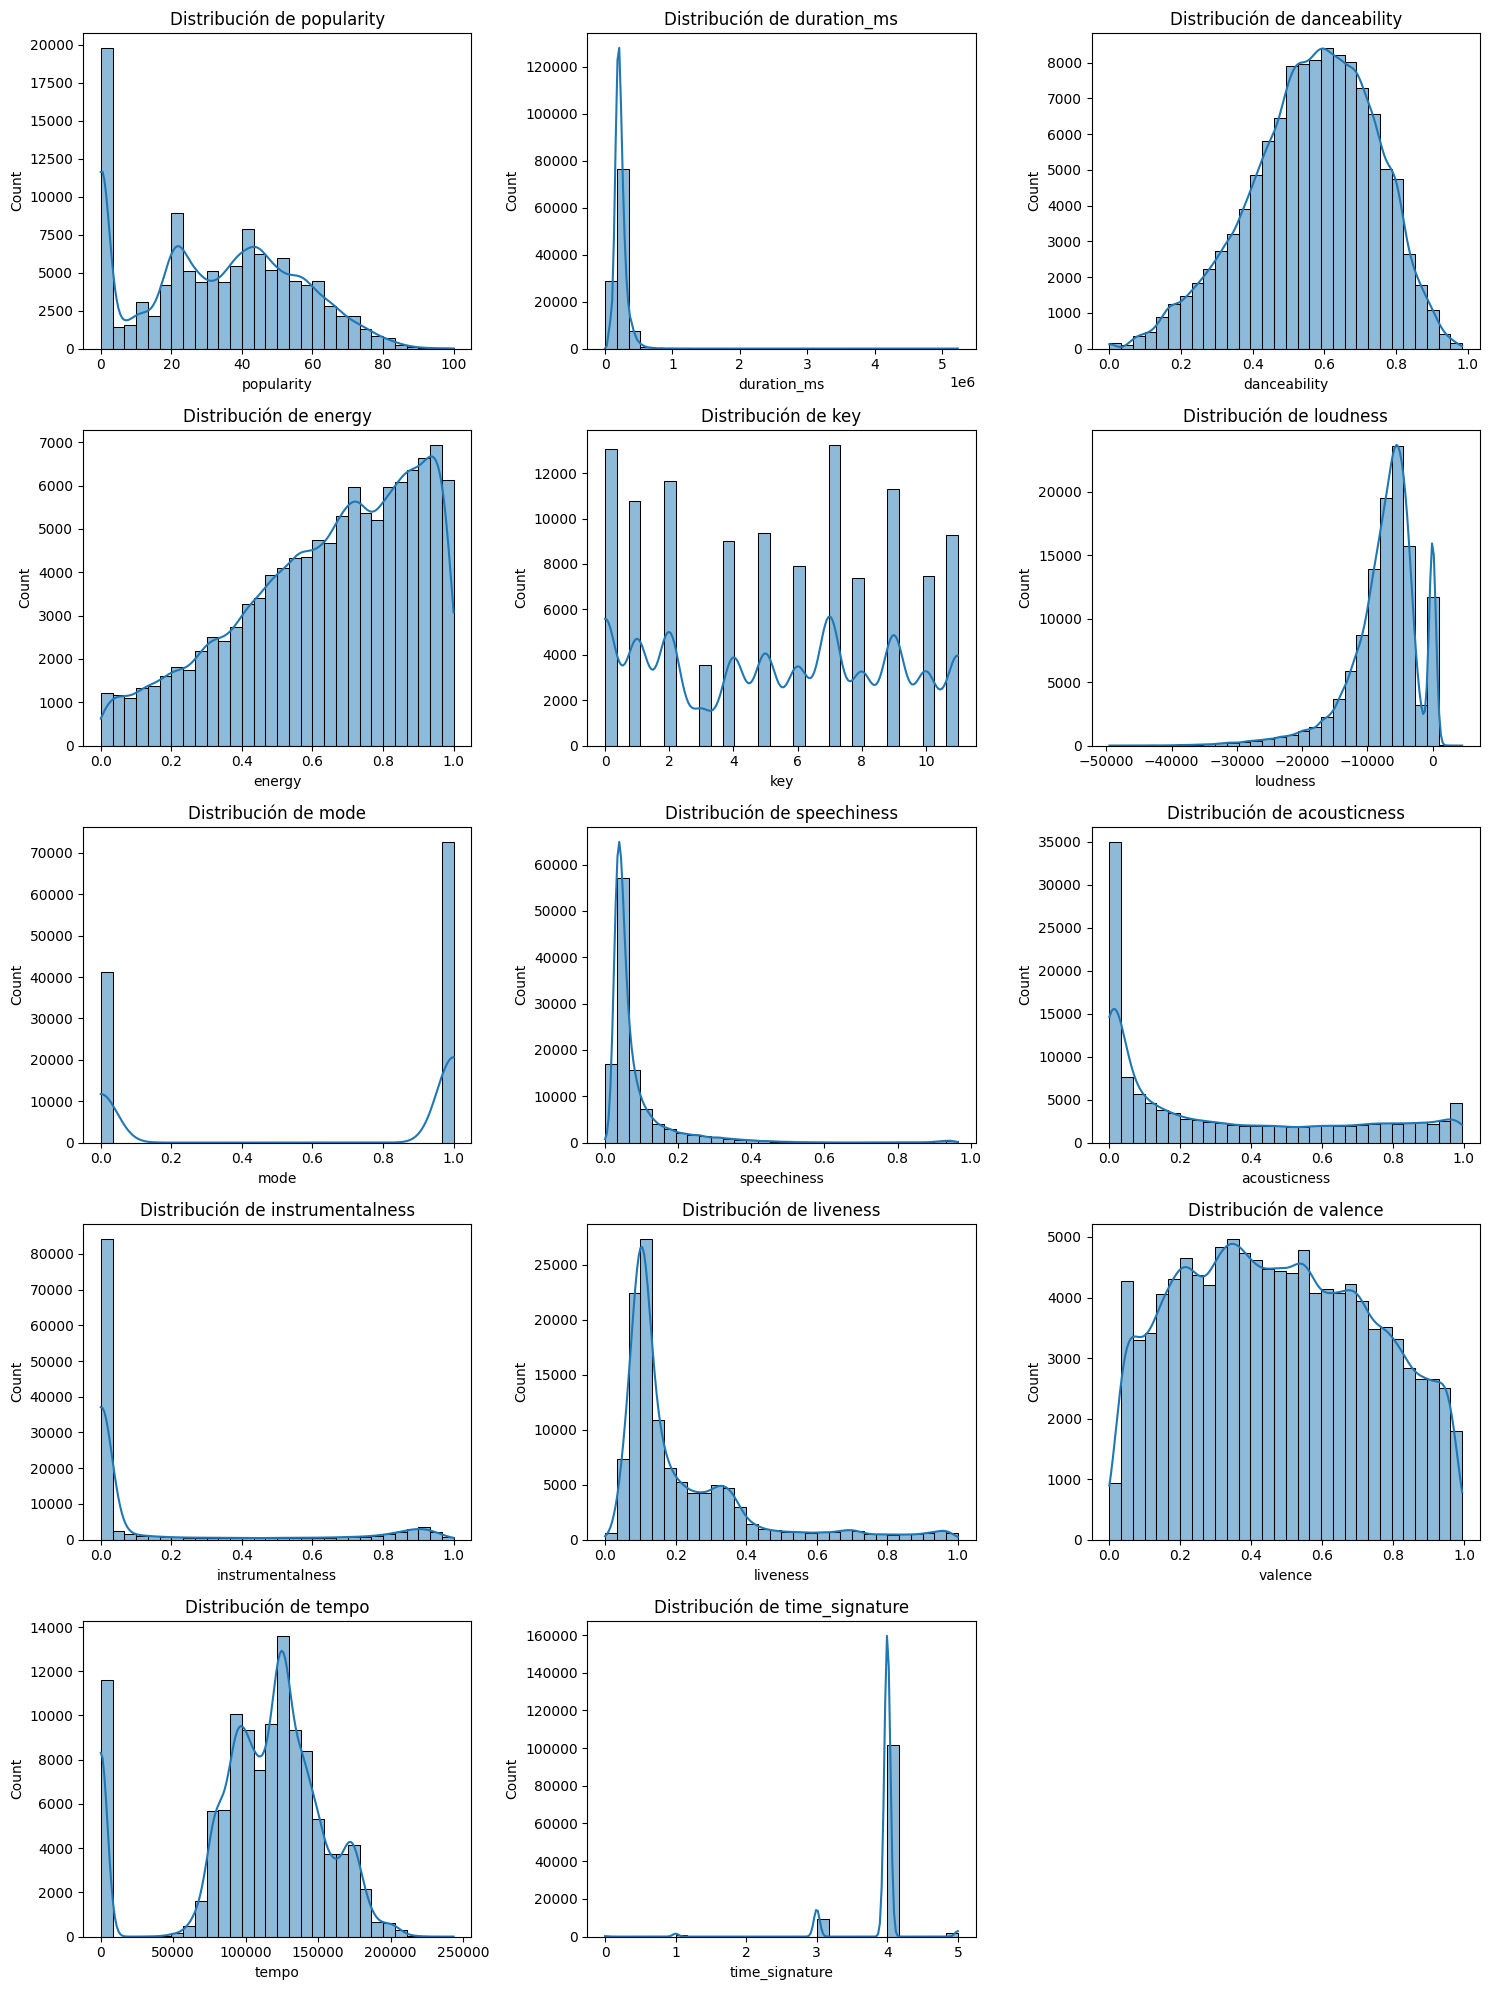

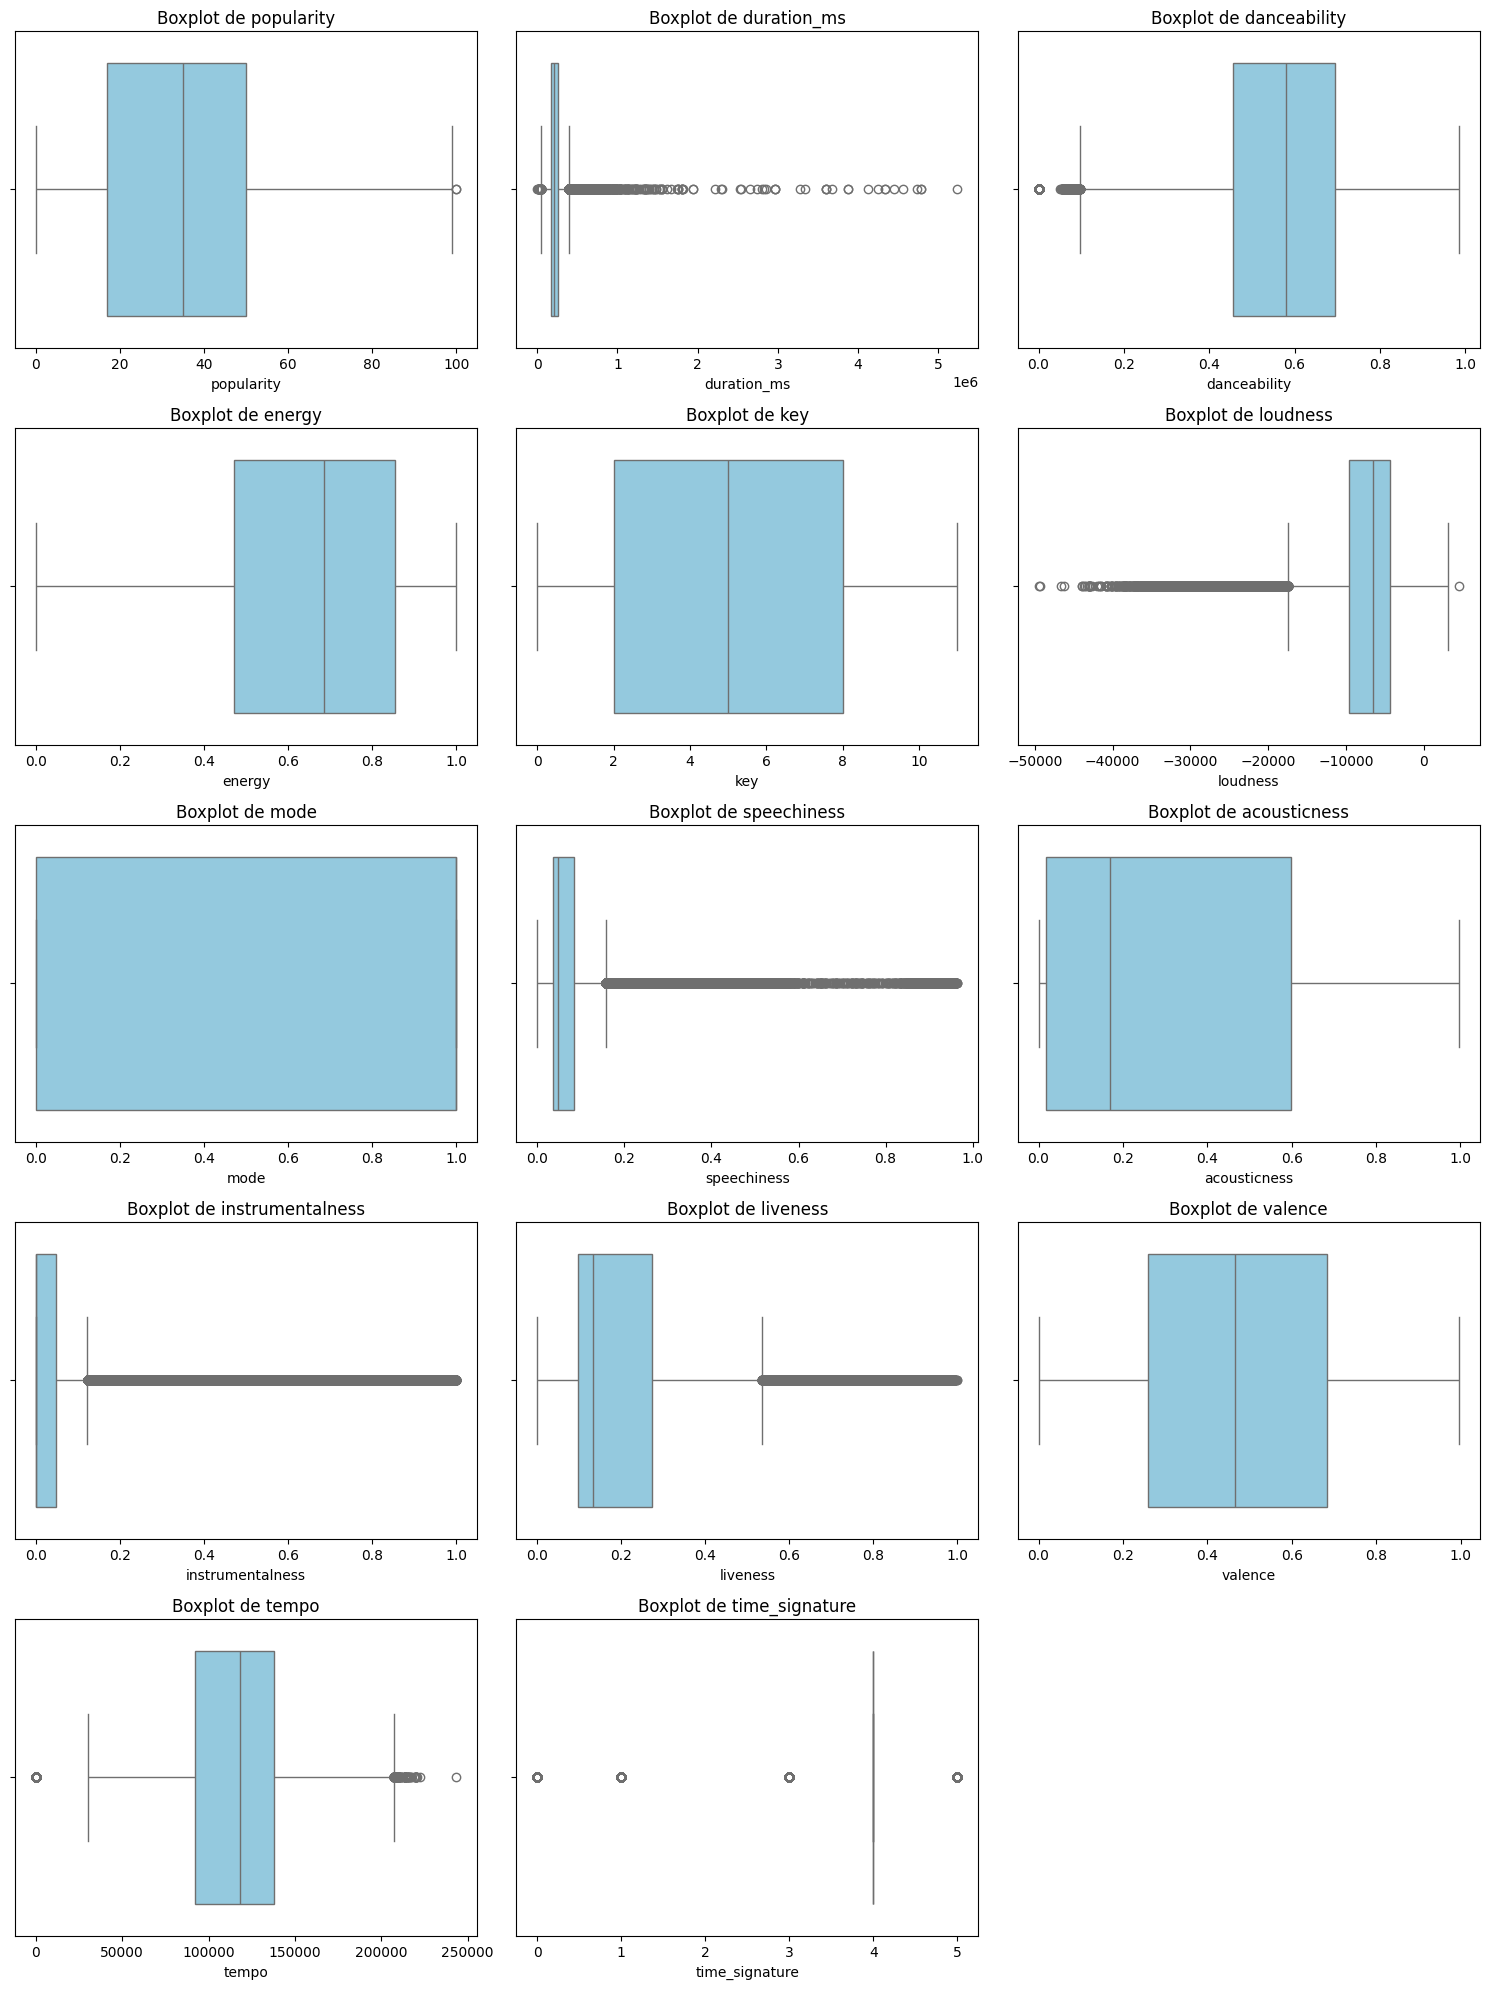

c:\Users\av-alumno\Desktop\Ev_1_MLY1101\utils\vis_descriptiva.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


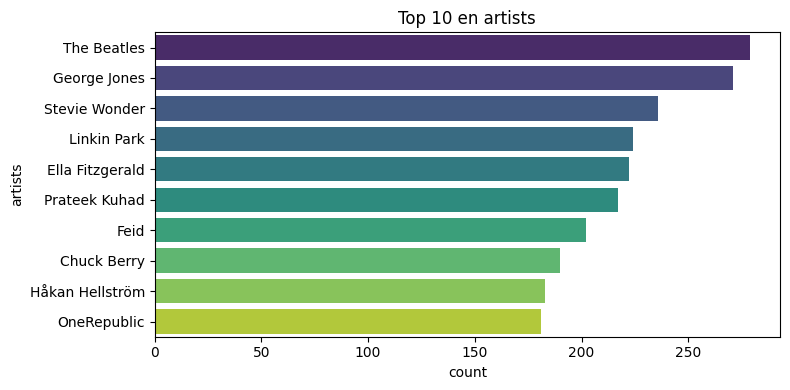

c:\Users\av-alumno\Desktop\Ev_1_MLY1101\utils\vis_descriptiva.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


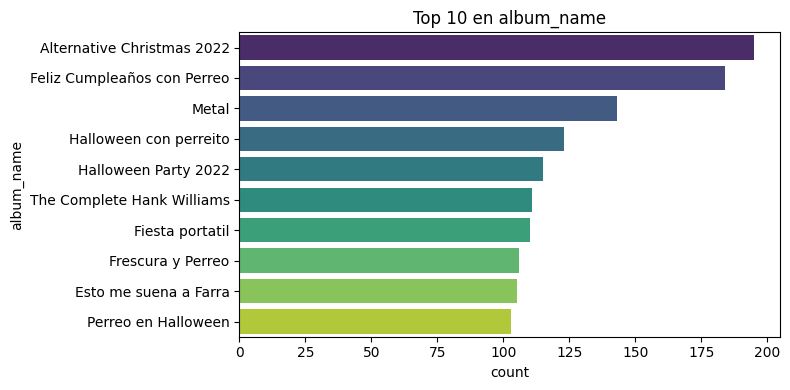

c:\Users\av-alumno\Desktop\Ev_1_MLY1101\utils\vis_descriptiva.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


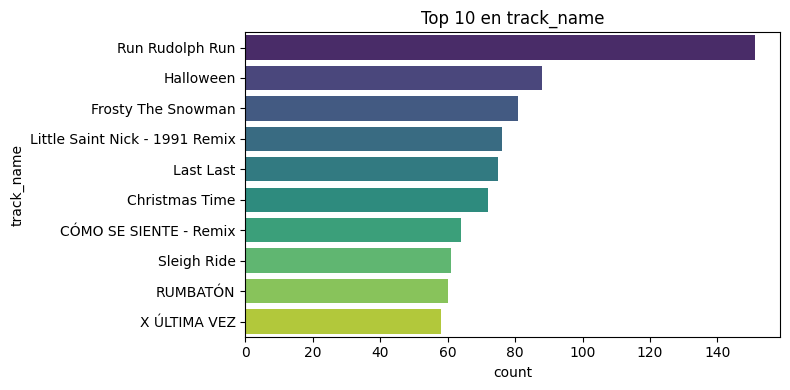

c:\Users\av-alumno\Desktop\Ev_1_MLY1101\utils\vis_descriptiva.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


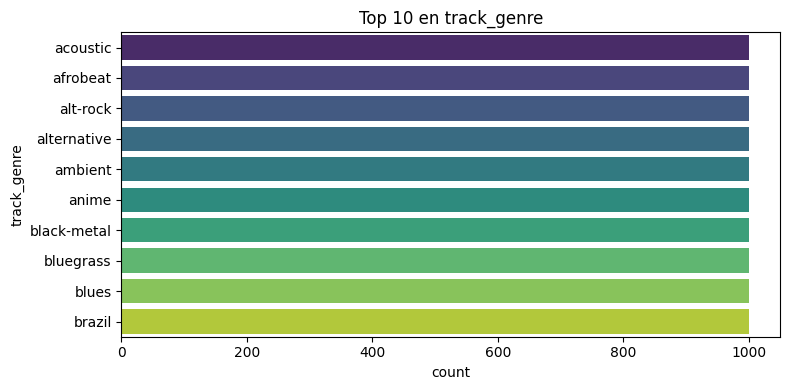

In [11]:
from utils.vis_descriptiva import (
    graficar_distribuciones_numericas,
    graficar_categoricas,
    graficar_boxplots
)

graficar_distribuciones_numericas(df)
graficar_boxplots(df)
graficar_categoricas(df)